In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The sklearn libraries are only for preparing and evaluating data
# The model is built from scratch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

In [64]:
# Loading the dataset
df = pd.read_csv('heart_disease.csv')
print(df.shape)
df.head()

(253680, 22)


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [65]:
X = df.drop('HeartDiseaseorAttack', axis=1)
Y = df['HeartDiseaseorAttack']

# Creating the train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test:", Y_test.shape)

X_train: (202944, 21)
X_test: (50736, 21)
Y_train: (202944,)
Y_test: (50736,)


In [66]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_final = X_train_scaled.T
X_test_final = X_test_scaled.T

Y_train_final = Y_train.values.reshape(1, -1)
Y_test_final = Y_test.values.reshape(1, -1)

print("X_train_final:", X_train_final.shape)
print("X_test_final:", X_test_final.shape)
print("Y_train_final:", Y_train_final.shape)
print("Y_test_final:", Y_test_final.shape)

X_train_final: (21, 202944)
X_test_final: (21, 50736)
Y_train_final: (1, 202944)
Y_test_final: (1, 50736)


In [67]:
class Layer:
    """Base class for a neural network layer."""

    def __init__(self, output_units, input_units, activation, initialization='he'):
        # He initialization: scales weights by sqrt(2 / input_units)
        # This keeps variance stable across layers when using ReLU activations
        if initialization == 'he':
            self.weights = np.random.randn(output_units, input_units) * np.sqrt(2 / input_units)

        # Simple random initialization (small scale to avoid saturation)
        if initialization == 'random':
            self.weights = np.random.randn(output_units, input_units) * 0.01

        self.biases = np.zeros((output_units, 1))
        self.activation = activation

    # Creating the three activation functions
    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))

    def relu(self, Z):
        return np.maximum(0, Z)

    def tanh(self, Z):
        return np.tanh(Z)

    # Computing the derivatives of the activation functions
    def activation_backwards(self, dA):
        # Computes dZ = dA * (derivative of the activation function)
        if self.activation == 'sigmoid':
            s = self.sigmoid(self.Z)
            grad = s * (1 - s)
            return dA * grad

        if self.activation == 'relu':
            grad = np.where(self.Z > 0, 1, 0)
            return dA * grad

        if self.activation == 'tanh':
            grad = 1 - self.tanh(self.Z) ** 2
            return dA * grad

    # Abstract methods: implemented in Dense (or other layer subclasses).
    def forward(self):
        pass

    def backward(self):
        pass

    def update(self):
        pass

In [68]:
class Dense(Layer):
    """Fully-connected layer: implements forward pass, backward pass, and parameter updates."""

    def __init__(self, output_units, input_units, activation, initialization='he'):
        super().__init__(output_units, input_units, activation, initialization=initialization)

    # Applying the formula z = wi + b and using the activation functions on z
    def forward(self, input):
        self.input = input
        Z = np.dot(self.weights, self.input) + self.biases
        self.Z = Z

        if self.activation == 'sigmoid':
            A = self.sigmoid(Z)
        elif self.activation == 'relu':
            A = self.relu(Z)
        elif self.activation == 'tanh':
            A = self.tanh(Z)

        self.A = A

        assert self.Z.shape == (self.weights.shape[0], self.A.shape[1])
        assert self.A.shape == (self.weights.shape[0], self.input.shape[1])

        return A

    # Backward propogation model
    def backward(self, dA_prev):
        dZ = self.activation_backwards(dA_prev)
        m = self.A.shape[1]

        # Calculating dW, db, and gradient to pass to the previous layer
        self.dW = np.dot(dZ, self.input.T) / m
        self.db = np.sum(dZ, axis=1, keepdims=True) / m
        dA_prev = np.dot(self.weights.T, dZ)

        assert dA_prev.shape == self.input.shape
        assert self.dW.shape == self.weights.shape
        assert self.db.shape == self.biases.shape

        return dA_prev

    def update(self, learning_rate):
        self.weights = self.weights - learning_rate * self.dW
        self.biases = self.biases - learning_rate * self.db

    def getWeights(self):
        return self.weights

    def getBiases(self):
        return self.biases

In [69]:
class Model:
    """Wraps a list of Layer objects into a trainable network."""

    def __init__(self):
        self.epsilon = 1e-8  # avoids log(0) in the cost function

    def build(self, network):
        """network: a list of Dense layer instances, in order."""
        self.network = network

    # Calls the forward() function for every layer
    def feedforward(self, X):
        input = X
        for layer in self.network:
            input = layer.forward(input)
        AL = input
        assert AL.shape == (1, X.shape[1])
        return AL

    # Implementing binary cross-entropy loss
    def compute_cost(self, m, AL, Y, pos_weight=1.0):
        cost = -1 / m * np.sum(
            pos_weight * Y * np.log(AL + self.epsilon) + (1 - Y) * np.log(1 - AL + self.epsilon)
        )
        return np.squeeze(cost)

    # Calls the backward() function for every layer in reverse
    def backpropagation(self, dAL):
        dA_prev = dAL
        for layer in reversed(self.network):
            dA_prev = layer.backward(dA_prev)

    def parameter_update(self, learning_rate):
        for layer in self.network:
            layer.update(learning_rate)

    # Runs one whole step (forward -> cost -> backward -> update)
    def train(self, X, Y, learning_rate, pos_weight=1.0):
        m = Y.shape[1]
        AL = self.feedforward(X)
        cost = self.compute_cost(m, AL, Y, pos_weight)

        Y = Y.reshape(AL.shape)
        dAL = -(pos_weight * Y / (AL + self.epsilon) - (1 - Y) / (1 - AL + self.epsilon))

        self.backpropagation(dAL)
        self.parameter_update(learning_rate)
        return cost

    # Runs a loop of multiple training steps
    def fit(self, X_train, Y_train, epochs, learning_rate, pos_weight=1.0, verbose=False, callback=None):
        costs = []
        for i in range(epochs):
            cost = self.train(X_train, Y_train, learning_rate, pos_weight)
            costs.append(cost)
            if i % 50 == 0:
                if verbose:
                    print(f"Iteration: {i}, cost: {cost}")
                if callback is not None:
                    callback(i, X_train, Y_train)
        return costs

    # Sets a threshold to produce binary result
    def predict(self, X):
        predictions = self.feedforward(X)
        return np.where(predictions > 0.5, 1, 0)

    def evaluate(self, predictions, Y):
        """Accuracy as a percentage."""
        return 100 - np.mean(np.abs(predictions - Y)) * 100

In [70]:
def plot_costs(costs):
    """Plots training cost vs. epoch."""
    plt.plot(costs)
    plt.xlabel('Epochs')
    plt.ylabel('Cost')
    plt.title('Training Cost over Time')
    return plt

In [71]:
# Using the training set to compute the pos_weight
pos_weight = (Y_train_final == 0).sum() / (Y_train_final == 1).sum()
print("pos_weight:", pos_weight)

# Creating a model with 21 -> 16 (ReLU) -> 8 (ReLU) -> 1 (sigmoid) architecture
model = Model()
network = [
    Dense(output_units=16, input_units=21, activation='relu'),
    Dense(output_units=8, input_units=16, activation='relu'),
    Dense(output_units=1, input_units=8, activation='sigmoid')
]
model.build(network)

pos_weight: 9.611450980392156


In [72]:
# Fitting the model
costs = model.fit(
    X_train_final, Y_train_final,
    epochs=500,
    learning_rate=0.01,
    pos_weight=pos_weight,
    verbose=True
)

Iteration: 0, cost: 1.3542676981622936
Iteration: 50, cost: 1.1756803426052538
Iteration: 100, cost: 1.1048573714470469
Iteration: 150, cost: 1.061740664315357
Iteration: 200, cost: 1.0317406701220195
Iteration: 250, cost: 1.0094838730993916
Iteration: 300, cost: 0.9922186359598321
Iteration: 350, cost: 0.9782792469894823
Iteration: 400, cost: 0.9668425713183081
Iteration: 450, cost: 0.9572902167205873


In [73]:
predictions_train = model.predict(X_train_final)
predictions_test = model.predict(X_test_final)

# Determining the train and test accuracy
train_accuracy = model.evaluate(predictions_train, Y_train_final)
test_accuracy = model.evaluate(predictions_test, Y_test_final)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

print("Class balance in full dataset:", Y.mean())
print("(i.e.", Y.mean()*100, "% of examples are positive class)")

Train Accuracy: 70.09569142226428
Test Accuracy: 70.1001261431725
Class balance in full dataset: 0.09418558814254178
(i.e. 9.418558814254178 % of examples are positive class)


[[31757 14211]
 [  959  3809]]
              precision    recall  f1-score   support

         0.0       0.97      0.69      0.81     45968
         1.0       0.21      0.80      0.33      4768

    accuracy                           0.70     50736
   macro avg       0.59      0.74      0.57     50736
weighted avg       0.90      0.70      0.76     50736



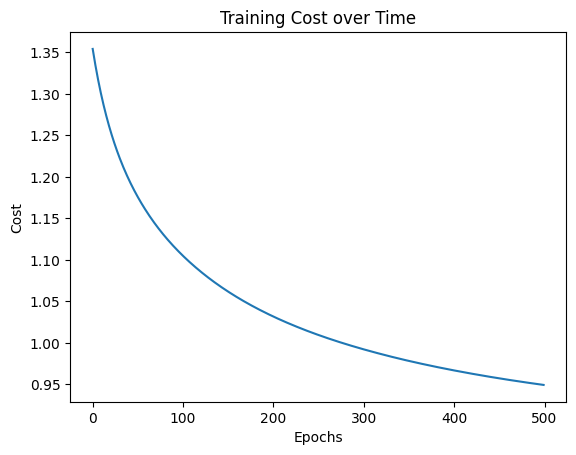

In [75]:
# Producing confusion matrix to determine false positives and negatives
print(confusion_matrix(Y_test_final.flatten(), predictions_test.flatten()))
print(classification_report(Y_test_final.flatten(), predictions_test.flatten()))

# Plotting the cost after every epoch
plot_costs(costs)
plt.show()